# SegFormer Trainer: Crown Closure from RGB + Elevation

What's in this notebook:

1. **`CrownClosureDataset`**: loads each patch's 4-channel input (RGB + elevation, normalized), the `crown_closure` target, the VRI validity mask, and a deterministic 80/20 pixel train/test split seeded by `patch_id`.
2. **Model**: starts from `Pranilllllll/segformer-satellite-segementation` (pretrained on real satellite imagery, not ADE20K photos), with the first conv expanded to 4 input channels and the classifier replaced with a single-channel regression head.
3. **Training loop**: resumable and checkpointed every epoch. `N_NEW_EPOCHS` adds epochs on top of whatever's already trained, resuming from the highest-numbered checkpoint under `models/segformer_crown_closure_epoch*`. Each epoch runs masked-MSE training and masked test-RMSE eval, then saves a checkpoint named with that epoch's test RMSE.
4. **Save, reload, test RMSE**: reloads the model fresh from its checkpoint to confirm the save works standalone, then reports final test RMSE.
5. **`predict_crown_closure()`**: runs the model on one patch and plots satellite, elevation, true, and predicted crown closure side by side.

## Why GPU (MPS) isn't used here

This notebook picks `cuda`, then `mps`, then `cpu`, and smoke-tests a real batch (`BATCH_SIZE=8`) forward+backward pass on whatever it picked. The smoke test fails on `mps` here:

```
RuntimeError: view size is not compatible with input tensor's size and stride
(at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
```

This is a real PyTorch MPS bug, not a config issue. Forward passes work fine on MPS; only backward fails, and only at batch size 2 or more. So training falls back to CPU: ~25-28 min/epoch instead of a few minutes.

A workaround exists: feed the model one sample at a time (small enough to dodge the crash) and accumulate gradients over 8 samples before calling `optimizer.step()`, which is mathematically equivalent to a real batch-8 gradient.

In [31]:
import os
import json
import glob
import re
import random
import time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerConfig, SegformerForSemanticSegmentation

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [32]:
SAT_OUT    = '/Volumes/Spleen/CABIN/datasets/patches/satellite_imagery'
DEM_OUT    = '/Volumes/Spleen/CABIN/datasets/patches/elevation'
CANOPY_OUT = '/Volumes/Spleen/CABIN/datasets/patches/crown_closure'
MASK_OUT   = '/Volumes/Spleen/CABIN/datasets/patches/crown_closure_mask'

SAVE_ROOT  = '/Volumes/Spleen/CABIN/models'
MODEL_NAME = 'segformer_crown_closure'

PATCH_SIZE_PX = 256
TEST_FRACTION = 0.20

RGB_MIN, RGB_MAX         = 0, 255
ELEV_MIN, ELEV_MAX       = 0, 4671
CLOSURE_MIN, CLOSURE_MAX = 0, 100

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print('device:', DEVICE)

os.makedirs(SAVE_ROOT, exist_ok=True)

patch_files = sorted(
    f for f in os.listdir(SAT_OUT) if f.startswith('patch_') and f.endswith('.png')
)
print(f'{len(patch_files)} patches')

def checkpoint_dir(epoch, test_rmse):
    return os.path.join(SAVE_ROOT, f'{MODEL_NAME}_epoch{epoch:03d}_testrmse{test_rmse:.2f}')

def find_latest_checkpoint():
    '''Returns the checkpoint dir with the highest epoch number, or None
    if no checkpoints exist yet. Epoch number (not test RMSE, which is
    not monotonic) is what determines "latest".'''
    candidates = glob.glob(os.path.join(SAVE_ROOT, f'{MODEL_NAME}_epoch*_testrmse*'))
    best_epoch, best_dir = -1, None
    for d in candidates:
        m = re.search(r'_epoch(\d+)_', os.path.basename(d))
        if m and int(m.group(1)) > best_epoch:
            best_epoch, best_dir = int(m.group(1)), d
    return best_dir

device: mps
5616 patches


In [33]:
class CrownClosureDataset(Dataset):
    '''One item = one full patch: a 4-channel input (r, g, b, elevation),
    the crown_closure target, the VRI validity mask, and a deterministic
    per-patch 80/20 pixel split mask (1 where a pixel is held out for
    test). The split is a pure function of (seed, patch_id), so it is
    identical every epoch and identical between the train and eval
    passes without needing to store it anywhere.'''

    def __init__(self, patch_files, seed=SEED):
        self.patch_files = patch_files
        self.seed = seed

    def __len__(self):
        return len(self.patch_files)

    def __getitem__(self, idx):
        filename = self.patch_files[idx]
        patch_id = int(filename[len('patch_'):-len('.png')])

        sat = np.array(Image.open(os.path.join(SAT_OUT, filename)).convert('RGB'), dtype=np.float32)
        sat_norm = (sat - RGB_MIN) / (RGB_MAX - RGB_MIN)

        # The DEM PNG already linearly encodes elevation over the fixed
        # 0-4671m range (mosaic_sampler.py), so /255 directly gives the
        # normalized-to-physical-bounds value.
        dem = np.array(Image.open(os.path.join(DEM_OUT, filename)).convert('L'), dtype=np.float32)
        elev_norm = dem / 255.0

        # crown_closure PNG stores the literal 0-100 percentage as-is
        # (not stretched to 0-255) — see save_canopy_png in mosaic_sampler.py.
        closure = np.array(Image.open(os.path.join(CANOPY_OUT, filename)).convert('L'), dtype=np.float32)
        closure_norm = (closure - CLOSURE_MIN) / (CLOSURE_MAX - CLOSURE_MIN)

        valid_mask = np.array(Image.open(os.path.join(MASK_OUT, filename)).convert('L'), dtype=np.float32) / 255.0

        x = np.concatenate([sat_norm.transpose(2, 0, 1), elev_norm[None]], axis=0).astype(np.float32)

        rng = np.random.default_rng(self.seed + patch_id)
        test_pixel_mask = (rng.random((PATCH_SIZE_PX, PATCH_SIZE_PX)) < TEST_FRACTION).astype(np.float32)

        return (
            torch.from_numpy(x),
            torch.from_numpy(closure_norm),
            torch.from_numpy(valid_mask),
            torch.from_numpy(test_pixel_mask),
            patch_id,
        )

In [34]:
BATCH_SIZE = 8

dataset = CrownClosureDataset(patch_files)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
eval_loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
latest_ckpt = find_latest_checkpoint()

if latest_ckpt is not None:
    print(f'Found existing checkpoint: {latest_ckpt} — resuming from it')
    model = SegformerForSemanticSegmentation.from_pretrained(latest_ckpt).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    optimizer.load_state_dict(torch.load(os.path.join(latest_ckpt, 'optimizer.pt'), map_location=DEVICE))
    with open(os.path.join(latest_ckpt, 'training_state.json')) as f:
        _state = json.load(f)
    epochs_trained = _state['epochs_trained']
    train_losses   = _state['train_losses']
    test_losses    = _state['test_losses']
    print(f'  {epochs_trained} epochs already trained, last test RMSE={test_losses[-1]:.3f}%')
else:
    print('No checkpoint found — starting from the pretrained satellite SegFormer')
    SEG_MODEL = 'Pranilllllll/segformer-satellite-segementation'
    model = SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL)

    # Expand the first patch-embedding conv from 3 channels (RGB) to 4
    # (RGB + elevation), keeping the pretrained RGB weights and initializing
    # the new elevation channel as the mean of the pretrained RGB weights
    # (a neutral starting point) rather than randomly reinitializing the
    # whole layer and losing the pretrained RGB features.
    old_proj = model.segformer.encoder.patch_embeddings[0].proj
    new_proj = torch.nn.Conv2d(
        4, old_proj.out_channels,
        kernel_size=old_proj.kernel_size, stride=old_proj.stride, padding=old_proj.padding,
    )
    with torch.no_grad():
        new_proj.weight[:, :3] = old_proj.weight
        new_proj.weight[:, 3]  = old_proj.weight.mean(dim=1)
        new_proj.bias[:] = old_proj.bias
    model.segformer.encoder.patch_embeddings[0].proj = new_proj
    model.config.num_channels = 4

    # Replace the 7-class land-use classifier with a fresh single-channel
    # regression head — no meaningful pretrained weights to carry over here.
    old_classifier = model.decode_head.classifier
    model.decode_head.classifier = torch.nn.Conv2d(old_classifier.in_channels, 1, kernel_size=1)
    model.config.num_labels = 1

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    epochs_trained = 0
    train_losses = []
    test_losses = []

n_params = sum(p.numel() for p in model.parameters())
print(f'{n_params:,} parameters')

Found existing checkpoint: /Volumes/Spleen/CABIN/models/segformer_crown_closure_epoch055_testrmse11.10 — resuming from it


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

  55 epochs already trained, last test RMSE=11.100%
3,715,969 parameters


In [36]:
try:
    smoke_x = torch.randn(BATCH_SIZE, 4, PATCH_SIZE_PX, PATCH_SIZE_PX, device=DEVICE)
    model(pixel_values=smoke_x).logits.sum().backward()
except RuntimeError as e:
    print(f'{DEVICE} failed a forward+backward smoke test, falling back to CPU: {e}')
    DEVICE = torch.device('cpu')
    model.to(DEVICE)
model.zero_grad()

# If we just resumed from a checkpoint, the optimizer's momentum buffers
# (exp_avg, exp_avg_sq) were loaded onto whatever DEVICE was at that
# point -- model.to(DEVICE) above only moves the model's parameters, not
# the optimizer's separately-stored state, so they can end up stranded
# on a different device after a fallback. Move them explicitly; this is
# a harmless no-op if they're already on the right device.
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(DEVICE)

print('using device:', DEVICE)

mps failed a forward+backward smoke test, falling back to CPU: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
using device: cpu


## Training

Benchmarked a real forward+backward pass on this machine before committing to a per-epoch cost (batch size 8, CPU — MPS hit the backward-pass bug noted above):

- **~1.19s / batch** on CPU for a training step (forward+backward)
- 5,616 patches / 8 per batch ≈ 702 batches/epoch → **~14 minutes/epoch** for training alone
- Every epoch now also runs a full **test-set evaluation pass** (forward-only, no backward) so each checkpoint can be named with that epoch's test RMSE — adds roughly another **~10-14 minutes/epoch**
- So each epoch costs **~25-28 minutes** end-to-end (train + eval + save)

**Resumable, checkpointed every epoch**: `N_NEW_EPOCHS` (below) is how many epochs *this run* adds — re-running the training cell later picks up from the highest-numbered checkpoint found in `SAVE_ROOT` and adds `N_NEW_EPOCHS` more, rather than starting over. Every epoch is saved individually as `segformer_crown_closure_epoch{N}_testrmse{RMSE}/`, so a crash mid-run only loses the epoch in progress, and you can compare any past epoch's checkpoint directly by its folder name.

In [37]:
N_NEW_EPOCHS = 100  # epochs to add on top of epochs_trained each time this cell runs

start_epoch = epochs_trained

for epoch in range(start_epoch, start_epoch + N_NEW_EPOCHS):
    model.train()
    epoch_start = time.time()
    running_sq_err = 0.0
    running_count = 0.0

    for X, Y, valid_mask, test_pixel_mask, _ in train_loader:
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        valid_mask, test_pixel_mask = valid_mask.to(DEVICE), test_pixel_mask.to(DEVICE)
        train_mask = valid_mask * (1 - test_pixel_mask)

        optimizer.zero_grad()
        logits = model(pixel_values=X).logits
        pred = F.interpolate(logits, size=(PATCH_SIZE_PX, PATCH_SIZE_PX), mode='bilinear', align_corners=False)[:, 0]

        sq_err = ((pred - Y) ** 2) * train_mask
        loss = sq_err.sum() / train_mask.sum().clamp(min=1)
        loss.backward()
        optimizer.step()

        running_sq_err += sq_err.sum().item()
        running_count  += train_mask.sum().item()

    train_mse = running_sq_err / running_count
    train_rmse = np.sqrt(train_mse) * (CLOSURE_MAX - CLOSURE_MIN)
    train_losses.append(train_rmse)

    # Test RMSE every epoch — needed since checkpoints are named with it.
    model.eval()
    test_sq_err_sum = 0.0
    test_count = 0.0
    with torch.no_grad():
        for X, Y, valid_mask, test_pixel_mask, _ in eval_loader:
            X, Y = X.to(DEVICE), Y.to(DEVICE)
            valid_mask, test_pixel_mask = valid_mask.to(DEVICE), test_pixel_mask.to(DEVICE)
            test_mask = valid_mask * test_pixel_mask

            logits = model(pixel_values=X).logits
            pred = F.interpolate(logits, size=(PATCH_SIZE_PX, PATCH_SIZE_PX), mode='bilinear', align_corners=False)[:, 0]

            sq_err = ((pred - Y) ** 2) * test_mask
            test_sq_err_sum += sq_err.sum().item()
            test_count      += test_mask.sum().item()

    test_mse = test_sq_err_sum / test_count
    test_rmse = np.sqrt(test_mse) * (CLOSURE_MAX - CLOSURE_MIN)
    test_losses.append(test_rmse)

    print(f'Epoch {epoch+1}  train RMSE={train_rmse:.3f}%  test RMSE={test_rmse:.3f}%  ({time.time()-epoch_start:.0f}s)')

    # Save every epoch, named with that epoch's test RMSE — a crash
    # mid-run only loses the epoch in progress, and re-running this cell
    # later resumes from the highest-numbered checkpoint found on disk.
    save_dir = checkpoint_dir(epoch + 1, test_rmse)
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    torch.save(optimizer.state_dict(), os.path.join(save_dir, 'optimizer.pt'))
    with open(os.path.join(save_dir, 'training_state.json'), 'w') as f:
        json.dump(
            {'epochs_trained': epoch + 1, 'train_losses': train_losses, 'test_losses': test_losses},
            f,
        )

epochs_trained = start_epoch + N_NEW_EPOCHS
print(f'Total epochs trained so far: {epochs_trained}')

Epoch 56  train RMSE=11.540%  test RMSE=11.014%  (1466s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 57  train RMSE=11.476%  test RMSE=11.038%  (1482s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 58  train RMSE=11.463%  test RMSE=10.951%  (1486s)


...

Epoch 85  train RMSE=10.834%  test RMSE=10.206%  (1496s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 86  train RMSE=10.792%  test RMSE=10.185%  (1493s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

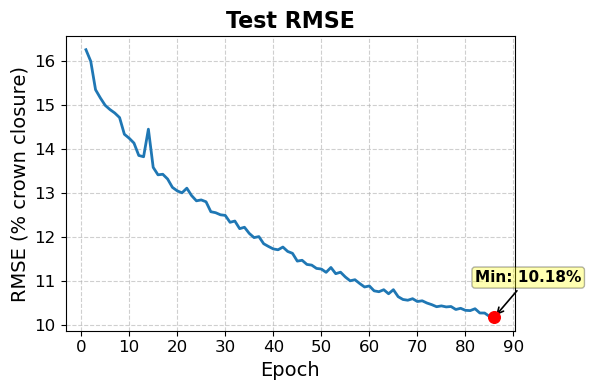

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

epochs_axis = np.array(range(1, len(train_losses) + 1))
test_losses_arr = np.array(test_losses)

# Find minimum test RMSE and corresponding epoch
min_idx = np.argmin(test_losses_arr)
min_epoch = epochs_axis[min_idx]
min_loss = test_losses_arr[min_idx]

plt.figure(figsize=(6, 4))
plt.plot(epochs_axis[:-1], test_losses, linewidth=2, markersize=6)

# Highlight minimum point with a distinct red dot
plt.scatter(min_epoch, min_loss, color='red', s=70, zorder=5)

# Annotate with an arrow and the exact value
plt.annotate(
    f'Min: {min_loss:.2f}%',
    xy=(min_epoch, min_loss),
    xytext=(min_epoch - 4, min_loss + 0.8),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3)
)

plt.xlabel('Epoch', fontsize=14)
plt.ylabel('RMSE (% crown closure)', fontsize=14)
plt.title('Test RMSE', fontsize=16, fontweight='bold')

# Set specific X-axis tick locations (0, 5, 10, 15, 20)
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90], fontsize=12)

# Force strictly whole numbers (integers) on the Y-axis
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../plots/test_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Reload from disk — the rest of the notebook uses this reloaded copy,
# not the in-memory `model` object, to confirm the saved checkpoint
# actually works standalone. Always pulls whichever checkpoint has the
# highest epoch number, regardless of how many resumed runs it took.
latest_ckpt = find_latest_checkpoint()
loaded_model = SegformerForSemanticSegmentation.from_pretrained(latest_ckpt)
loaded_model.to(DEVICE)
loaded_model.eval()
print('Reloaded model from', latest_ckpt)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Reloaded model from /Volumes/Spleen/CABIN/models/segformer_crown_closure_epoch020_testrmse13.05


In [22]:
test_sq_err_sum = 0.0
test_count = 0.0

with torch.no_grad():
    for X, Y, valid_mask, test_pixel_mask, _ in eval_loader:
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        valid_mask, test_pixel_mask = valid_mask.to(DEVICE), test_pixel_mask.to(DEVICE)
        test_mask = valid_mask * test_pixel_mask

        logits = loaded_model(pixel_values=X).logits
        pred = F.interpolate(logits, size=(PATCH_SIZE_PX, PATCH_SIZE_PX), mode='bilinear', align_corners=False)[:, 0]

        sq_err = ((pred - Y) ** 2) * test_mask
        test_sq_err_sum += sq_err.sum().item()
        test_count      += test_mask.sum().item()

test_mse = test_sq_err_sum / test_count
test_rmse = np.sqrt(test_mse) * (CLOSURE_MAX - CLOSURE_MIN)

print(f'Test RMSE: {test_rmse:.3f}%  crown closure  (n={int(test_count):,} valid test pixels)')

Test RMSE: 15.993%  crown closure  (n=50,047,835 valid test pixels)


Patch 2: mean predicted crown closure = 38.1%


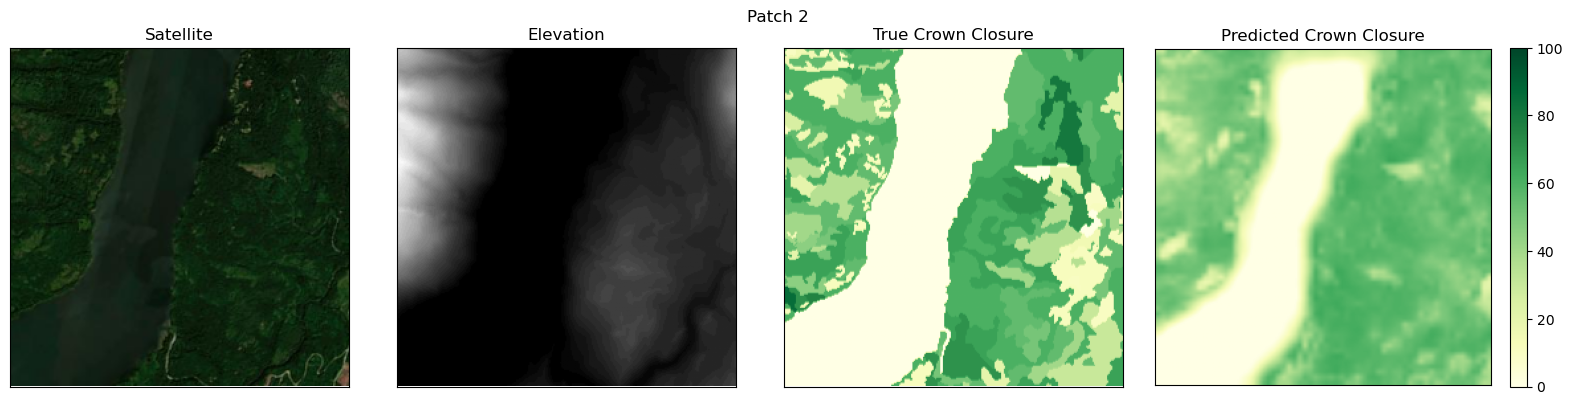

In [27]:
def predict_crown_closure(model, patch_id, plot=True):
    '''Runs the model on one patch and returns its predicted crown_closure
    map (256x256, 0-100 scale). Optionally plots RGB / elevation / true
    closure / predicted closure side by side.'''
    filename = f'patch_{patch_id:04d}.png'

    sat = np.array(Image.open(os.path.join(SAT_OUT, filename)).convert('RGB'), dtype=np.float32)
    sat_norm = (sat - RGB_MIN) / (RGB_MAX - RGB_MIN)
    dem = np.array(Image.open(os.path.join(DEM_OUT, filename)).convert('L'), dtype=np.float32)
    elev_norm = dem / 255.0

    x = np.concatenate([sat_norm.transpose(2, 0, 1), elev_norm[None]], axis=0).astype(np.float32)
    x_t = torch.from_numpy(x).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(pixel_values=x_t).logits
        pred = F.interpolate(logits, size=(PATCH_SIZE_PX, PATCH_SIZE_PX), mode='bilinear', align_corners=False)[0, 0]

    pred_closure = (pred.cpu().numpy() * (CLOSURE_MAX - CLOSURE_MIN)).clip(CLOSURE_MIN, CLOSURE_MAX)
    print(f'Patch {patch_id}: mean predicted crown closure = {pred_closure.mean():.1f}%')

    if plot:
        true_closure = np.array(Image.open(os.path.join(CANOPY_OUT, filename)).convert('L'), dtype=np.float32)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(sat.astype(np.uint8))
        axes[0].set_title('Satellite')
        axes[1].imshow(dem, cmap='gray')
        axes[1].set_title('Elevation')
        axes[2].imshow(true_closure, cmap='YlGn', vmin=0, vmax=100)
        axes[2].set_title('True Crown Closure')
        im = axes[3].imshow(pred_closure, cmap='YlGn', vmin=0, vmax=100)
        axes[3].set_title('Predicted Crown Closure')
        for ax in axes:
            ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=axes[3], fraction=0.046)
        fig.suptitle(f'Patch {patch_id}')
        plt.tight_layout()
        plt.show()

    return pred_closure


# Example usage
_ = predict_crown_closure(loaded_model, patch_id=2)